## Data preparation

In [29]:
%cd /home/maia-user/NeuroCBIR/
!ls

/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/maia-user/NeuroCBIR
cbir		       data			 preprocessing		utils
CBIR.ipynb	       global_AE_training.ipynb  README.md
CBIR_wholeBrain.ipynb  main.ipynb		 seg_preparation.ipynb
compute_SVF.ipynb      model			 training


In [30]:
# # Loading MRI  paths
from preprocessing.nii2npy import convert_nii_to_npy
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label
import numpy as np
import os

dataset_path = "/home/maia-user/Dataset/ADNI/"
file_paths, file_names = list_files_with_extension(dataset_path, extension="align_aparc+aseg.nii.gz")

raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('/')[1] for file_path in file_paths])  # e.g., "OAS30001"


In [31]:
# import torch
# from model.autoencoder import Conv3DSparseAutoencoder
# from torchsummary import summary

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Input size: [160, 176, 208]
# input_size = [64, 80, 48]

# # Initialize model and move it to the correct device
# autoencoder = Conv3DSparseAutoencoder().to(device)

# # Run summary — torchsummary will match the device of the model
# _=summary(autoencoder, (1, *input_size))

In [32]:
import sys
print(sys.executable)


/usr/bin/python3


In [33]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

In [24]:
import voxelmorph as vxm
import neurite as ne

In [6]:
np.load('/home/maia-user/Dataset/OASIS3_NPY_UINT/OAS30531_MR_d1347.npy', allow_pickle=True)

array({'image': array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
       

In [ ]:
# our data will be of shape 160 x 192 x 224
vol_shape = (160, 192, 224)
nb_features = [
    [16, 32, 32, 32],
    [32, 32, 32, 32, 32, 16, 16]
]

In [8]:
# build vxm network
vxm_model = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=7);

2025-05-14 17:28:37.705351: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [9]:
val_volume_1 = np.load('data/tutorial_data/subj1.npz')['vol']
seg_volume_1 = np.load('data/tutorial_data/subj1.npz')['seg']
val_volume_2 = np.load('data/tutorial_data/subj2.npz')['vol']
seg_volume_2 = np.load('data/tutorial_data/subj2.npz')['seg']

val_input = [
    val_volume_1[np.newaxis, ..., np.newaxis],
    val_volume_2[np.newaxis, ..., np.newaxis]
]

In [ ]:
val_volume_1.shape

(160, 192, 224)

In [11]:
vxm_model.load_weights('data/tutorial_data/brain_3d.h5')

In [12]:
val_pred = vxm_model.predict(val_input)

1/1 [==============================] - 36s 36s/step


In [13]:
moved_pred = val_pred[0].squeeze()
pred_warp = val_pred[1]

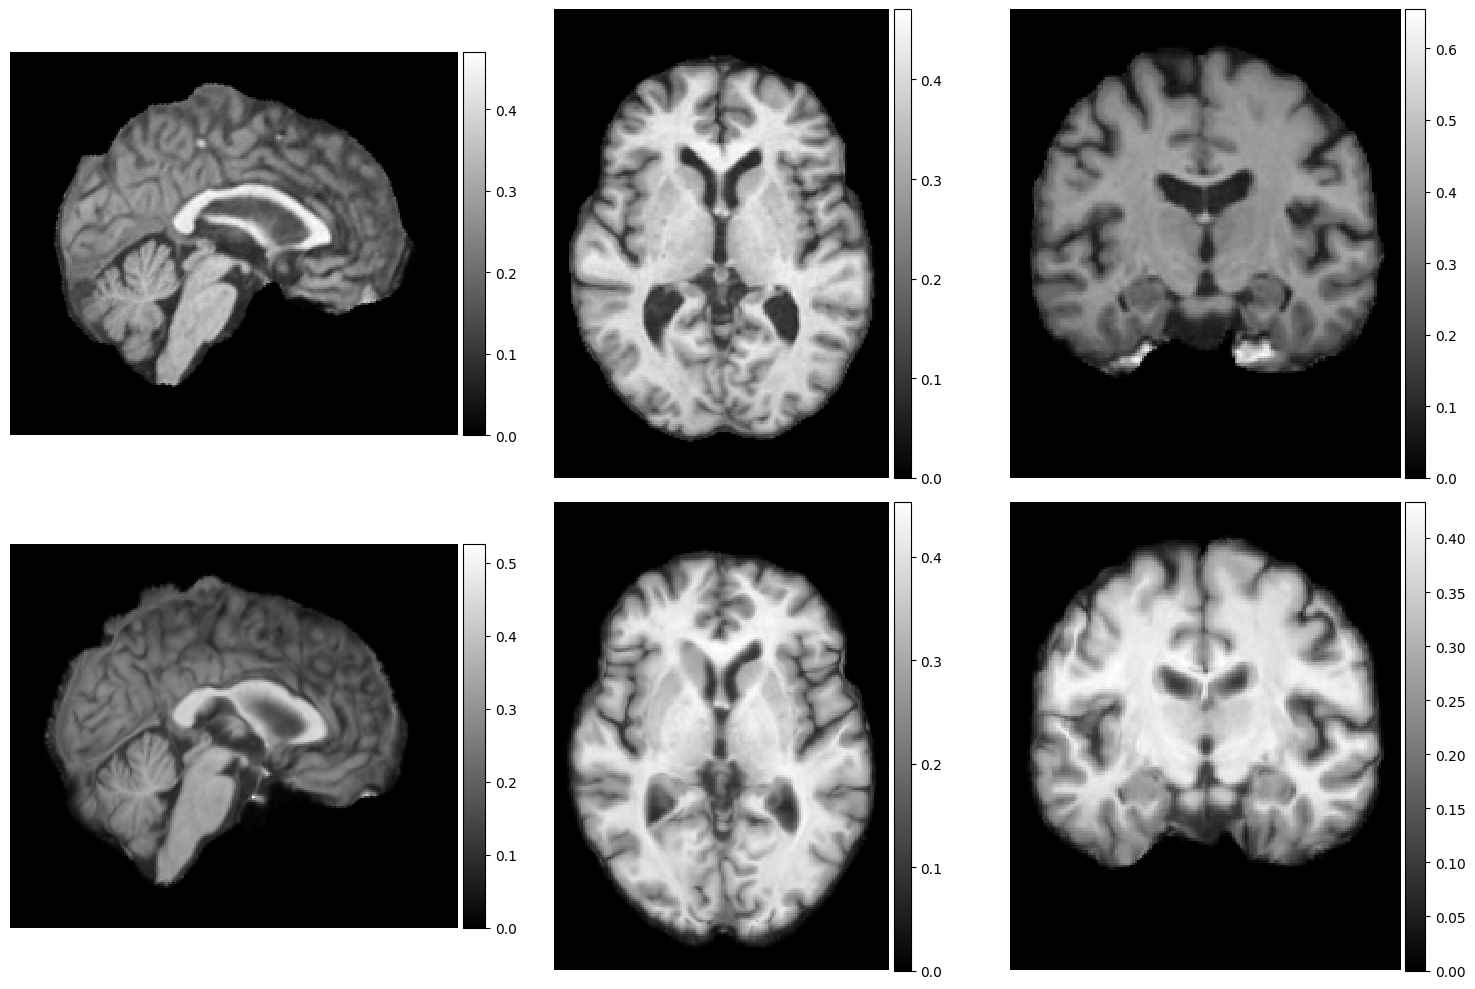

In [14]:
mid_slices_fixed = [np.take(val_volume_2, vol_shape[d]//2, axis=d) for d in range(3)]
mid_slices_fixed[1] = np.rot90(mid_slices_fixed[1], 1)
mid_slices_fixed[2] = np.rot90(mid_slices_fixed[2], -1)

mid_slices_pred = [np.take(moved_pred, vol_shape[d]//2, axis=d) for d in range(3)]
mid_slices_pred[1] = np.rot90(mid_slices_pred[1], 1)
mid_slices_pred[2] = np.rot90(mid_slices_pred[2], -1)
ne.plot.slices(mid_slices_fixed + mid_slices_pred, cmaps=['gray'], do_colorbars=True, grid=[2,3]);

In [15]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_UINT/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')

# Some recordings might be removed, i.e. nan labels
raw_labels = np.array([get_label(image_id, labels_df) for image_id in raw_image_ids]).astype('float32')
raw_ages = np.array([get_label(image_id, labels_df, column='age_at_visit') for image_id in raw_image_ids]).astype('float32')
raw_ids = np.array([get_label(image_id, labels_df, column='OASISID') for image_id in raw_image_ids])

# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages = raw_ages[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)

/home/maia-user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2681,) (2680,)


(160, 192, 224) 0.70980394 0.0


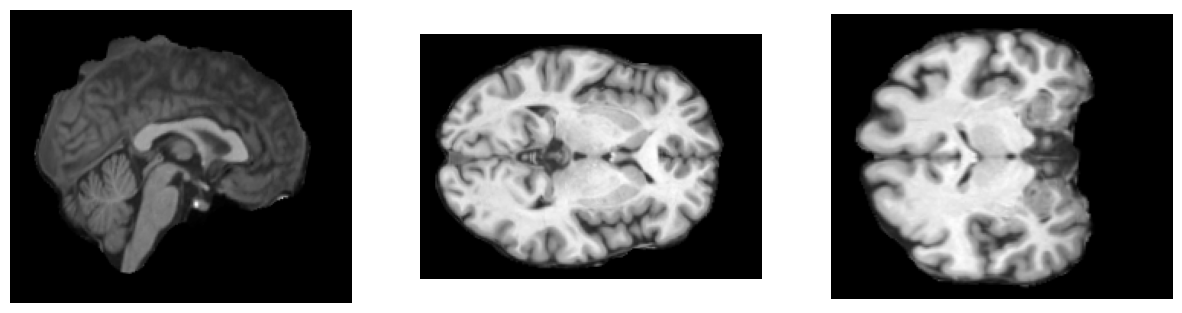

(160, 192, 224) 0.5 0.0


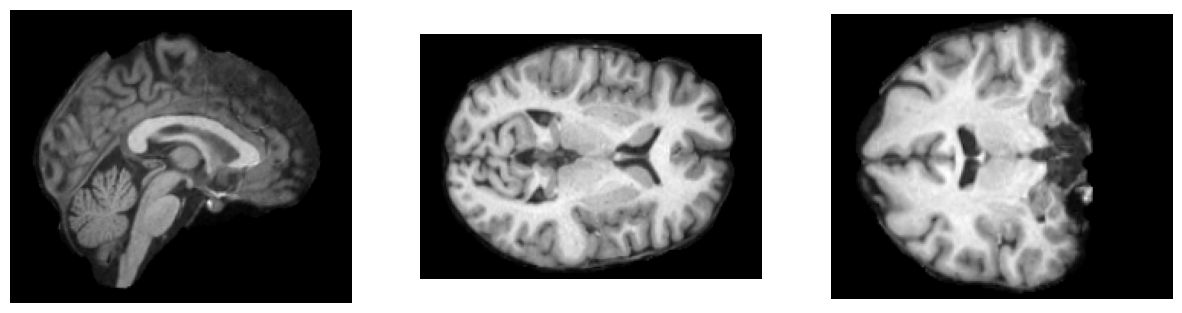

In [16]:
import numpy as np

def pad_mri_to_shape(volume, target_shape, symmetric=True):
    """
    Pad a 3D MRI volume with zeros to the target shape.

    Parameters:
        volume (np.ndarray): The input 3D array (e.g., shape (160, 176, 208))
        target_shape (tuple): The desired shape (e.g., (160, 192, 224))
        symmetric (bool): If True, pads evenly on both sides. If False, pads at the end.

    Returns:
        np.ndarray: Zero-padded volume with shape == target_shape
    """
    assert volume.ndim == 3, "Input volume must be 3D"
    assert all(t >= v for t, v in zip(target_shape, volume.shape)), "Target shape must be >= input shape in all dimensions"
    
    pad_width = []
    for i in range(3):
        total_pad = target_shape[i] - volume.shape[i]
        if symmetric:
            before = total_pad // 2
            after = total_pad - before
        else:
            before = 0
            after = total_pad
        pad_width.append((before, after))

    padded_volume = np.pad(volume, pad_width=pad_width, mode='constant', constant_values=0)
    return padded_volume

def plot_mri_sample(mri_data):
    # Show a single slice (assuming 3D MRI data)
    print(mri_data.shape, np.max(mri_data), np.min(mri_data))
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
    axes[0].axis("off")
    axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
    axes[1].axis("off")
    axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
    axes[2].axis("off")
    plt.show()

target_shape = (160, 192, 224)
img_seg = np.load(image_paths[0], allow_pickle=True).item()
my_vol = np.flip(np.transpose(img_seg['image'], (2, 0, 1)), 2) * 0.5 / 255.0 # Transform to match dimensions
my_vol_reshaped = pad_mri_to_shape(my_vol, target_shape)

plot_mri_sample(val_volume_1) # voxelmorph example input data
plot_mri_sample(my_vol_reshaped)


In [17]:
from tensorflow.keras.models import load_model
import voxelmorph as vxm

vxm_model = load_model(
    'data/tutorial_data/vxm_dense_brain_T1_3D_mse.h5',
    custom_objects={'VxmDense': vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0)},
    compile=False
)

vxm_model.summary()


/home/maia-user/.local/lib/python3.10/site-packages/voxelmorph/tf/networks.py:124: UserWarning: int_downsize is deprecated, use the int_resolution parameter.
  warnings.warn('int_downsize is deprecated, use the int_resolution parameter.')
/home/maia-user/.local/lib/python3.10/site-packages/voxelmorph/tf/networks.py:129: UserWarning: unet_half_res is deprecated, use the svf_resolution parameter.
  warnings.warn('unet_half_res is deprecated, use the svf_resolution parameter.')


Model: "vxm_dense"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 vxm_dense_source_input (In  [(None, 160, 192, 224, 1)]   0         []                            
 putLayer)                                                                                        
                                                                                                  
 vxm_dense_target_input (In  [(None, 160, 192, 224, 1)]   0         []                            
 putLayer)                                                                                        
                                                                                                  
 vxm_dense_unet_input_conca  (None, 160, 192, 224, 2)     0         ['vxm_dense_source_input[0][0]
 t (Concatenate)                                                    ',                    

In [18]:
img_seg.keys()

dict_keys(['image', 'seg'])

In [ ]:
import numpy as np
import os
from tqdm import tqdm
from joblib import Parallel, delayed

# === PARAMETERS ===
path_to_save = "/home/maia-user/Dataset/OASIS3_NPY_SVF/"
target_shape = (160, 192, 224)
subjects = np.unique(ids)

# === HELPER FUNCTION ===
def process_pair(i, j, subject_image_paths, subject_ages, subject_labels):
    image_path_moving, age_moving, label_moving = subject_image_paths[i], subject_ages[i], subject_labels[i]
    image_path_fixed, age_fixed, label_fixed = subject_image_paths[j], subject_ages[j], subject_labels[j]

    im_seg_moving = np.load(image_path_moving, allow_pickle=True).item()
    im_seg_fixed = np.load(image_path_fixed, allow_pickle=True).item()

    moving_image = im_seg_moving['image']
    fixed_image = im_seg_fixed['image']

    # Preprocess
    moving_image = np.flip(np.transpose(moving_image, (2, 0, 1)), 2)
    fixed_image = np.flip(np.transpose(fixed_image, (2, 0, 1)), 2)
    moving_image = pad_mri_to_shape(moving_image, target_shape) * 0.5 / 255.0
    fixed_image = pad_mri_to_shape(fixed_image, target_shape) * 0.5 / 255.0

    vxm_input = [
        moving_image[np.newaxis, ..., np.newaxis],
        fixed_image[np.newaxis, ..., np.newaxis]
    ]

    # Predict deformation
    data_pred = vxm_model.predict(vxm_input, verbose=0)
    moved_image = data_pred[0].squeeze()
    pred_warp = data_pred[1].squeeze()

    # Transform back
    pred_warp = np.transpose(np.flip(pred_warp, 2), (1, 2, 0, 3)).astype(np.float16)

    moving_name = image_path_moving.split(dataset_path)[-1].split('.npy')[0]
    target_name = image_path_fixed.split(dataset_path)[-1].split('.npy')[0]
    save_path = os.path.join(path_to_save, f"FROM__{moving_name}__TO__{target_name}.npy")
    np.save(save_path, pred_warp)

# === PROCESS IN PARALLEL ===
use_parallel=False
for subject in tqdm(subjects, desc="Subjects"):
    subject_ages = ages[ids == subject]
    sort_indexes = np.argsort(subject_ages)

    subject_image_paths = image_paths[ids == subject][sort_indexes]
    subject_ages = subject_ages[sort_indexes]
    subject_labels = labels[ids == subject][sort_indexes]

    jobs = []
    for i in range(len(subject_image_paths) - 1):
        for j in range(i+1, len(subject_image_paths)):
            jobs.append((i, j))

    if use_parallel:

        Parallel(n_jobs=2)(delayed(process_pair)(i, j, subject_image_paths, subject_ages, subject_labels)
                        for i, j in jobs)
    else:
        for i, j in jobs:
            process_pair(i, j, subject_image_paths, subject_ages, subject_labels)


Subjects:  40%|███▉      | 525/1315 [3:19:46<5:47:36, 26.40s/it] 

(192, 224, 160) 0.5 0.0


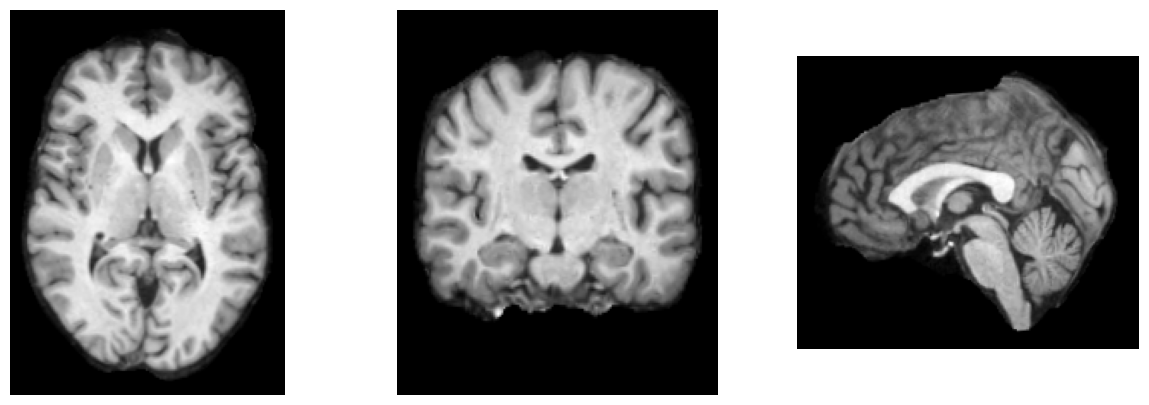

(192, 224, 160) 0.5 0.0


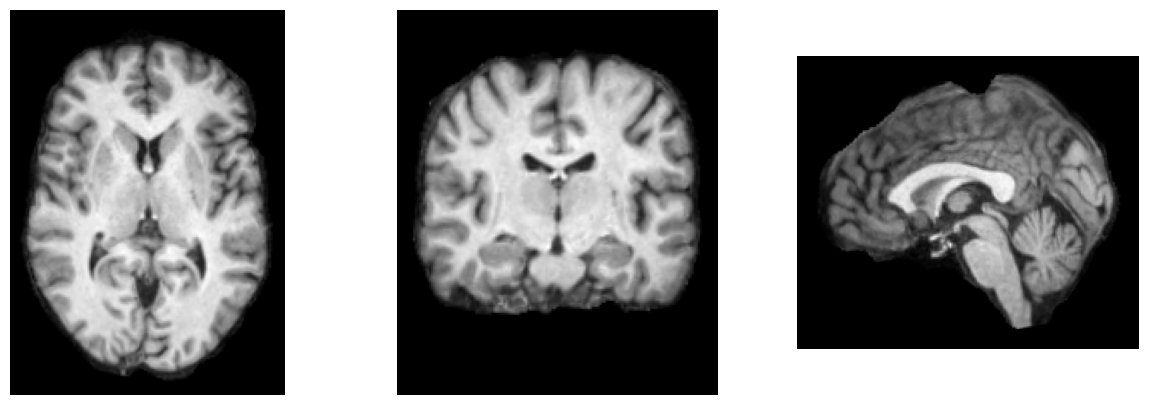

(192, 224, 160) 0.47673795 0.0


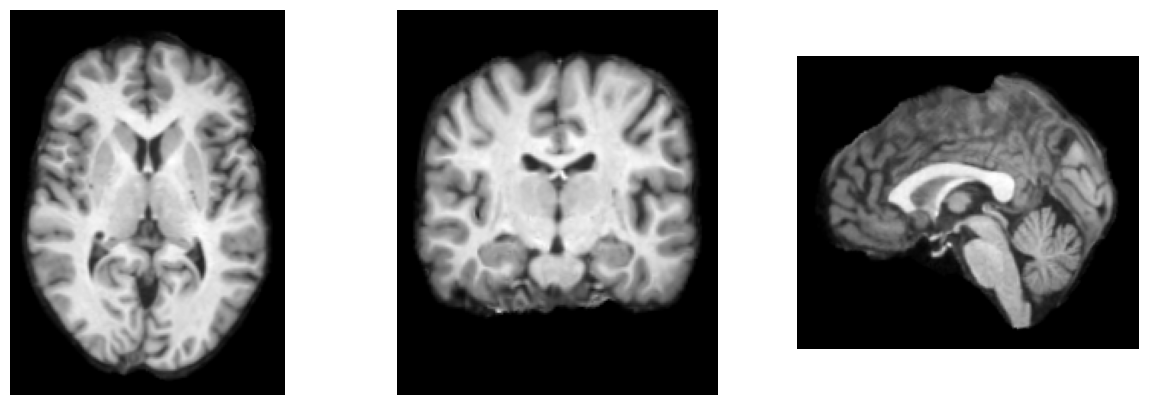

(96, 112, 80, 3)


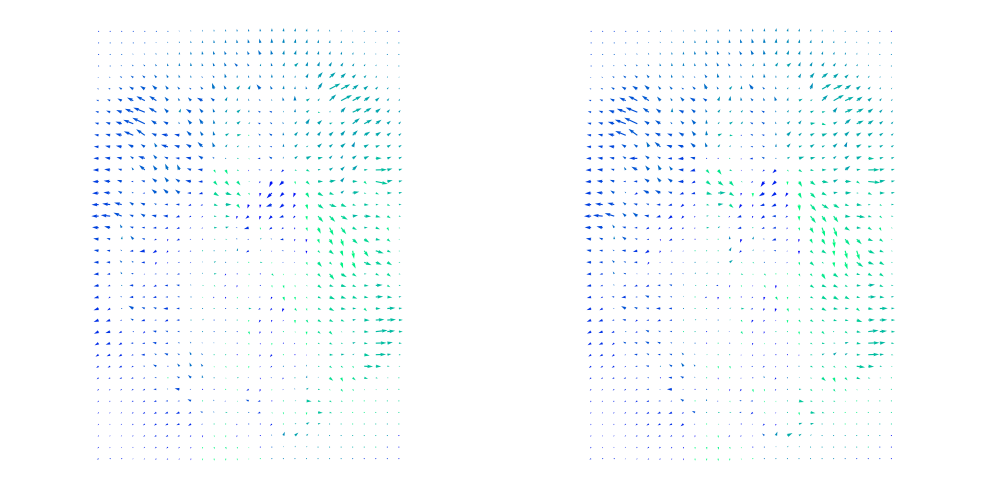

In [75]:
plot_mri_sample(moving_image)
plot_mri_sample(fixed_image)
plot_mri_sample(moved_image)
print(pred_warp.shape)
ne.plot.flow(pred_warp[40:42, ::3, ::3, 0:2].astype(np.float16), width=10);